# Trabajo Práctico: Perceptrón Multicapa (MLP) desde Cero

En este trabajo práctico se implementará un MLP de una capa oculta utilizando exclusivamente operaciones escalares (sin matrices ni operaciones vectorizadas de NumPy).

Se empleará el conjunto de datos *Breast Cancer* de scikit-learn, seleccionando tres características: `mean area`, `mean texture` y `mean smoothness`. La diferencia de escala entre estas variables permitirá ilustrar la importancia del preprocesamiento.

## Objetivos
1. Implementar el forward pass y backpropagation neurona por neurona.
2. Aplicar descenso de gradiente estocástico (SGD), actualizando cada peso y bias conforme a la regla de la cadena.
3. Observar el efecto del escalamiento de variables (*feature scaling*) sobre la convergencia.
4. Implementar *Early Stopping* para prevenir sobreajuste.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from pyexpat import features

from holoviews.plotting.bokeh.styles import font_size
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'font.size': 12,
})

## 1. Carga de Datos y Particiones

Se divide el dataset en tres conjuntos: **Train** (60%), **Validación** (20%) y **Test** (20%).  
El conjunto de validación se usará para monitorear el sobreajuste durante el entrenamiento; el de test, para evaluar el desempeño final.

In [50]:
data = load_breast_cancer()
X = data.data[:, [3, 1, 4]]  # mean area, mean texture, mean smoothness
y = data.target

# Separar 20% para Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Del 80% restante, separar 25% (≈20% del total) para Validación
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},   y_test:  {y_test.shape}")

X_train: (341, 3), y_train: (341,)
X_val:   (114, 3),  y_val:   (114,)
X_test:  (114, 3),   y_test:  (114,)


## 2. Análisis Exploratorio y Feature Scaling

Antes de entrenar, es necesario inspeccionar las distribuciones de las tres variables.  
A partir de lo observado (rangos, presencia de outliers, forma de la distribución), justifique cuál de los tres scalers disponibles resulta más adecuado.

In [51]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

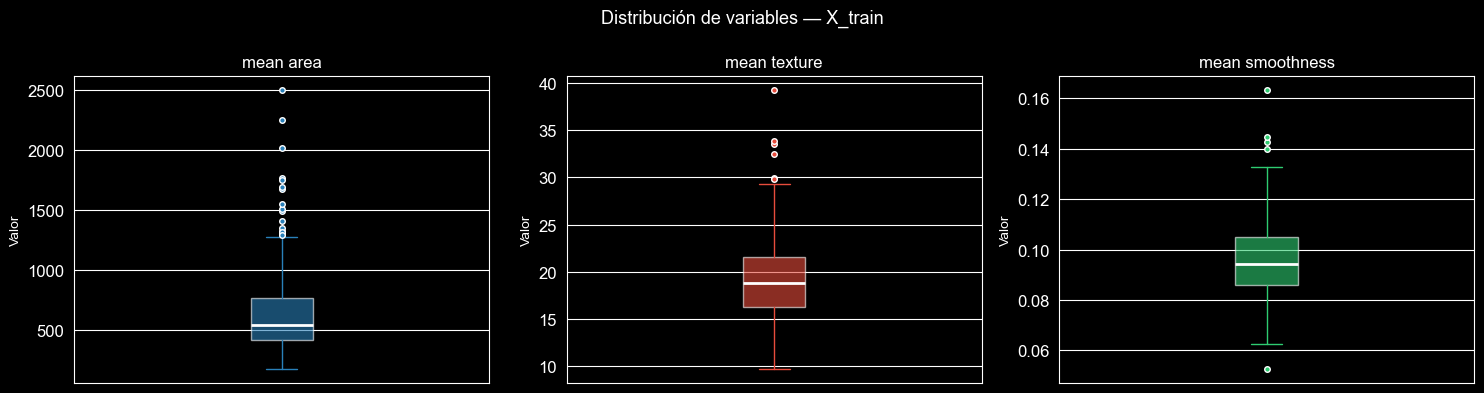

Medias post-scaling: [0.301 0.059 0.08 ]
Std   post-scaling: [0.997 0.8   0.756]


In [52]:
# TODO: Visualice la distribución de las 3 variables del conjunto de entrenamiento.
# Sugerencia: histogramas (plt.hist) o boxplots (plt.boxplot).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['mean area', 'mean texture', 'mean smoothness']
colores  = ['#2980b9', '#e74c3c', '#2ecc71']

for i, (ax, feat, color) in enumerate(zip(axes, features, colores)):
    bp = ax.boxplot(X_train[:, i],
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(marker='o', color=color,
                                   markerfacecolor=color, markersize=4))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.6)

    ax.set_title(feat, fontsize=12)
    ax.set_ylabel('Valor', fontsize=10)
    ax.set_xticks([])
    ax.tick_params(colors='white')

plt.suptitle('Distribución de variables — X_train', fontsize=13)
plt.tight_layout()
plt.show()

# RobustScaler justificado por outliers visibles en mean area
scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train)   # fit SOLO en train
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Medias post-scaling:", X_train_s.mean(axis=0).round(3))
print("Std   post-scaling:", X_train_s.std(axis=0).round(3))


**Justificación de la elección del scaler:**  
*Escriba aquí su análisis.*

In [53]:
# TODO: Instancie el scaler elegido.
# Ajuste (fit) exclusivamente sobre X_train, luego transforme los tres conjuntos.

# scaler = ...

**Justificación de la elección del scaler:**

Los boxplots nos pueden  mostrar tres comportamientos distintos en nuestra variables:

- `mean area` presenta valores del orden de cientos a miles con outliers
  extremos visibles por encima del bigote superior rango típico [143, 2501].
- `mean texture` y `mean smoothness` esatn operando en escalas mucho menores
  (decenas y centésimas respectivamente) con outliers mas moderados.

Como `mean area` tiene outliers crticos, se descarta `StandardScaler`
porque su media y desviación estándar son sensibles a valores extremos
un outlier en `mean area` produciría valores estandarizados $z > 5$ que
saturarían la función sigmoide desde la primera época, generando gradientes
cercanos a cero y esto bloquearia el aprendizaje.

`MinMaxScaler` tampoco seria adecuado, porque comprime todo al rango $[0, 1]$
usando el mínimo y máximo observados un único outlier extremo aplastaria
todos los demás valores hacia cero.

`RobustScaler` es la elección que podemos considerar correta: usa la **mediana** y el **IQR**
(rango intercuartílico) en lugar de media y desviación estándar, siendo
inherentemente insensible a outliers:

$$x_{\text{scaled}} = \frac{x - \text{mediana}(x)}{\text{IQR}(x)}$$

Esto garantiza que los outliers de `mean area` no distorsionen la
escala del resto de nuestros datos y eso nos permite que el gradiente fluya
correctamente durante el backpropagation (Géron, 2022).

> **Nota:** las medias post-scaling no son exactamente 0 ni las
> desviaciones exactamente 1, esto se debe a `RobustScaler`
> ya que no normaliza respecto a la media sino a la mediana.

---

**Referencias**

> Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn,
> Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

## 3. Arquitectura e Inicialización

La red tiene la siguiente estructura:
- **Entrada**: 3 nodos (uno por variable).
- **Capa oculta**: 4 neuronas con activación sigmoide.
- **Capa de salida**: 1 neurona con activación sigmoide (clasificación binaria).
- **Función de costo**: Error Cuadrático Medio (MSE).

**Conteo de parámetros:**  
- Capa oculta: $3 \times 4 = 12$ pesos + $4$ bias = **16 parámetros**.  
- Capa de salida: $4 \times 1 = 4$ pesos + $1$ bias = **5 parámetros**.  
- **Total: 21 parámetros**.

In [54]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_d(z):
    s = sigmoid(z)
    return s * (1 - s)

In [55]:
# Inicialización de pesos y bias (valores pequeños aleatorios)
np.random.seed(42)

# --- Capa 1 (oculta) ---
# Notación: w_jk_L → peso de la entrada k hacia la neurona j, en la capa L
w11_1, w12_1, w13_1 = np.random.rand(3) * 0.1  # neurona 1
w21_1, w22_1, w23_1 = np.random.rand(3) * 0.1  # neurona 2
w31_1, w32_1, w33_1 = np.random.rand(3) * 0.1  # neurona 3
w41_1, w42_1, w43_1 = np.random.rand(3) * 0.1  # neurona 4

b1_1, b2_1, b3_1, b4_1 = np.random.rand(4) * 0.1

# --- Capa 2 (salida) ---
w11_2, w12_2, w13_2, w14_2 = np.random.rand(4) * 0.1

b1_2 = np.random.rand() * 0.1

## 4. Bucle de Entrenamiento

A continuación se implementará el ciclo completo de entrenamiento escalar:
1. **Forward pass**: propagar cada muestra por la red, neurona por neurona.
2. **Cálculo del costo**: MSE para la muestra actual.
3. **Backpropagation**: calcular los deltas y gradientes para cada peso y bias usando la regla de la cadena.
4. **Actualización de parámetros**: aplicar SGD ($w \leftarrow w - \eta \cdot \nabla w$).
5. **Evaluación sobre validación**: calcular el loss promedio en el conjunto de validación.
6. **Early Stopping**: detener el entrenamiento si no hay mejora.

### 4.1 Early Stopping

El *Early Stopping* es una técnica de regularización que evita el sobreajuste deteniendo el entrenamiento antes de completar todas las épocas programadas.

**Principio:** durante el entrenamiento, el loss de entrenamiento tiende a disminuir de forma monótona. Sin embargo, el loss de validación típicamente decrece hasta cierto punto y luego comienza a aumentar, indicando que el modelo empieza a memorizar los datos de entrenamiento en lugar de aprender patrones generalizables.

**Mecanismo:**
1. Al finalizar cada época, se calcula el loss promedio sobre el conjunto de validación (`val_loss`).
2. Se compara con el mejor loss de validación registrado hasta el momento (`best_val_loss`).
3. Si `val_loss < best_val_loss`, hay mejora: se actualiza `best_val_loss` y se reinicia un contador de paciencia.
4. Si no hay mejora, se incrementa el contador de paciencia.
5. Cuando el contador alcanza el límite de paciencia (`patience_limit`), se interrumpe el entrenamiento con `break`.

En este trabajo usaremos `patience_limit = 10`, es decir, detenemos el entrenamiento si transcurren 10 épocas consecutivas sin mejora en el loss de validación.

> **Nota:** en una implementación completa, se guardaría una copia de los parámetros correspondientes al mejor `val_loss` y se restauraría al finalizar. Para este ejercicio, cuyo objetivo es practicar las operaciones escalares, omitiremos ese paso.

### 4.2 Cálculo del Loss de Validación por Época

Al finalizar cada época de entrenamiento, se necesita evaluar el modelo sobre el conjunto de validación para obtener `val_loss`. Este cálculo es análogo al proceso de predicción que se realizó en el ejemplo de clase (`mlp_fixed_MSE_ex`): se ejecuta únicamente el **forward pass** sobre cada muestra de validación, **sin actualizar los pesos**.

La estructura es la siguiente:

```python
epoch_val_loss = 0
for i in range(len(X_val)):
    # 1. Extraer las entradas: X_val[i, 0], X_val[i, 1], X_val[i, 2]
    # 2. Ejecutar el forward pass (capa oculta → capa de salida) con los pesos actuales
    # 3. Calcular el error MSE para esta muestra: (y_val[i] - y_pred) ** 2
    # 4. Acumular: epoch_val_loss += error
```

Observe que la estructura es idéntica al bloque de predicción sobre test visto en clase, con la diferencia de que aquí se acumula el error en lugar de contar aciertos. El resultado `val_loss = epoch_val_loss / len(X_val)` se utiliza para alimentar el mecanismo de Early Stopping descrito arriba.

**Tarea:** implemente este bloque dentro del bucle de entrenamiento, justo después de la sección de entrenamiento de cada época.

In [56]:
lr = 0.5
epochs = 300
patience_limit = 10
patience_counter = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(epochs):
    epoch_train_loss = 0
    
    # ===================== ENTRENAMIENTO =====================
    for i in range(len(X_train_s)):
        a1_0 = X_train_s[i, 0]
        a2_0 = X_train_s[i, 1]
        a3_0 = X_train_s[i, 2]
        y_true = y_train[i]
        
        # TODO: Forward pass escalar (capa oculta → capa de salida)
        ##Foirward pass capa oculta
        z1_1 = w11_1*a1_0 + w12_1*a2_0 + w13_1*a3_0 + b1_1
        z2_1 = w21_1*a1_0 + w22_1*a2_0 + w23_1*a3_0 + b2_1
        z3_1 = w31_1*a1_0 + w32_1*a2_0 + w33_1*a3_0 + b3_1
        z4_1 = w41_1*a1_0 + w42_1*a2_0 + w43_1*a3_0 + b4_1

        a1_1 = sigmoid(z1_1)
        a2_1 = sigmoid(z2_1)
        a3_1 = sigmoid(z3_1)
        a4_1 = sigmoid(z4_1)

        ##Forward pass  capa de salida
        z1_2 = w11_2*a1_1 + w12_2*a2_1 + w13_2*a3_1 + w14_2*a4_1 + b1_2
        a1_2 = sigmoid(z1_2) # nuesrra prediccion final
        
        # TODO: Calcular el MSE de esta muestra
        loss = (y_true - a1_2)**2
        epoch_train_loss += loss
        
        
        # TODO: Backpropagation — calcular deltas (salida, luego oculta)
        ##Backpropagatoin detala mas la cap de salida
        ## dL/da * da/dz = -2(y - ^y) * o'(z)
        delta_out = -2 * (y_true - a1_2) * sigmoid_d(z1_2)
        
        # TODO: Calcular gradientes para cada peso y bias
        ##gradietnes capas e salida
        dw11_2 = delta_out * a1_1
        dw12_2 = delta_out * a2_1
        dw13_2 = delta_out * a3_1
        dw14_2 = delta_out * a4_1
        db1_2  = delta_out

        # Backpropagation — deltas capa oculta
        # delta_j = (w_j2 * delta_out) * σ'(z_j)
        delta1_1 = (w11_2 * delta_out) * sigmoid_d(z1_1)
        delta2_1 = (w12_2 * delta_out) * sigmoid_d(z2_1)
        delta3_1 = (w13_2 * delta_out) * sigmoid_d(z3_1)
        delta4_1 = (w14_2 * delta_out) * sigmoid_d(z4_1)

        # Gradientes capa oculta — neurona 1
        dw11_1 = delta1_1 * a1_0
        dw12_1 = delta1_1 * a2_0
        dw13_1 = delta1_1 * a3_0
        db1_1  = delta1_1

        # Gradientes capa oculta — neurona 2
        dw21_1 = delta2_1 * a1_0
        dw22_1 = delta2_1 * a2_0
        dw23_1 = delta2_1 * a3_0
        db2_1  = delta2_1

        # Gradientes capa oculta — neurona 3
        dw31_1 = delta3_1 * a1_0
        dw32_1 = delta3_1 * a2_0
        dw33_1 = delta3_1 * a3_0
        db3_1  = delta3_1

        # Gradientes capa oculta — neurona 4
        dw41_1 = delta4_1 * a1_0
        dw42_1 = delta4_1 * a2_0
        dw43_1 = delta4_1 * a3_0
        db4_1  = delta4_1
        
        # TODO: Actualizar parámetros con SGD
        # SGD — actualización de parámetros
        # Capa de salida
        w11_2 -= lr * dw11_2
        w12_2 -= lr * dw12_2
        w13_2 -= lr * dw13_2
        w14_2 -= lr * dw14_2
        b1_2  -= lr * db1_2

        # Capa oculta — neurona 1
        w11_1 -= lr * dw11_1
        w12_1 -= lr * dw12_1
        w13_1 -= lr * dw13_1
        b1_1  -= lr * db1_1

        # Capa oculta — neurona 2
        w21_1 -= lr * dw21_1
        w22_1 -= lr * dw22_1
        w23_1 -= lr * dw23_1
        b2_1  -= lr * db2_1

        # Capa oculta — neurona 3
        w31_1 -= lr * dw31_1
        w32_1 -= lr * dw32_1
        w33_1 -= lr * dw33_1
        b3_1  -= lr * db3_1

        # Capa oculta — neurona 4
        w41_1 -= lr * dw41_1
        w42_1 -= lr * dw42_1
        w43_1 -= lr * dw43_1
        b4_1  -= lr * db4_1
        
    train_losses.append(epoch_train_loss / len(X_train_s))
    
    # ===================== VALIDACIÓN =====================
    epoch_val_loss = 0
    
    for i in range(len(X_val)):
        # TODO: Ejecutar solo el forward pass sobre X_val[i]
        # (mismo procedimiento de predicción visto en clase)
        # y acumular el error MSE en epoch_val_loss
        a1_0 = X_val_s[i, 0]
        a2_0 = X_val_s[i, 1]
        a3_0 = X_val_s[i, 2]

        # Forward pass — capa oculta
        z1_1 = w11_1*a1_0 + w12_1*a2_0 + w13_1*a3_0 + b1_1
        z2_1 = w21_1*a1_0 + w22_1*a2_0 + w23_1*a3_0 + b2_1
        z3_1 = w31_1*a1_0 + w32_1*a2_0 + w33_1*a3_0 + b3_1
        z4_1 = w41_1*a1_0 + w42_1*a2_0 + w43_1*a3_0 + b4_1

        a1_1 = sigmoid(z1_1)
        a2_1 = sigmoid(z2_1)
        a3_1 = sigmoid(z3_1)
        a4_1 = sigmoid(z4_1)

        # Forward pass — capa de salida
        z1_2  = w11_2*a1_1 + w12_2*a2_1 + w13_2*a3_1 + w14_2*a4_1 + b1_2
        a1_2  = sigmoid(z1_2)

        epoch_val_loss += (y_val[i] - a1_2) ** 2
        
    val_loss_avg = epoch_val_loss / len(X_val)
    val_losses.append(val_loss_avg)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_loss_avg:.4f}")
        
    # TODO: Implementar Early Stopping
    # Comparar val_loss_avg con best_val_loss.
    # Si hay mejora: actualizar best_val_loss y reiniciar patience_counter.
    # Si no hay mejora: incrementar patience_counter; si alcanza patience_limit, break.
    if val_loss_avg < best_val_loss:
        best_val_loss    = val_loss_avg
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"\nEarly Stopping en epoch {epoch}, el Val Loss no mejora en {patience_limit} épocas.")
            break

Epoch 0  , Train Loss: 0.1707, Val Loss: 0.0819
Epoch 10 , Train Loss: 0.0552, Val Loss: 0.0606
Epoch 20 , Train Loss: 0.0516, Val Loss: 0.0565
Epoch 30 , Train Loss: 0.0499, Val Loss: 0.0539
Epoch 40 , Train Loss: 0.0492, Val Loss: 0.0536

Early Stopping en epoch 49, el Val Loss no mejora en 10 épocas.


## 5. Evaluación y Visualización

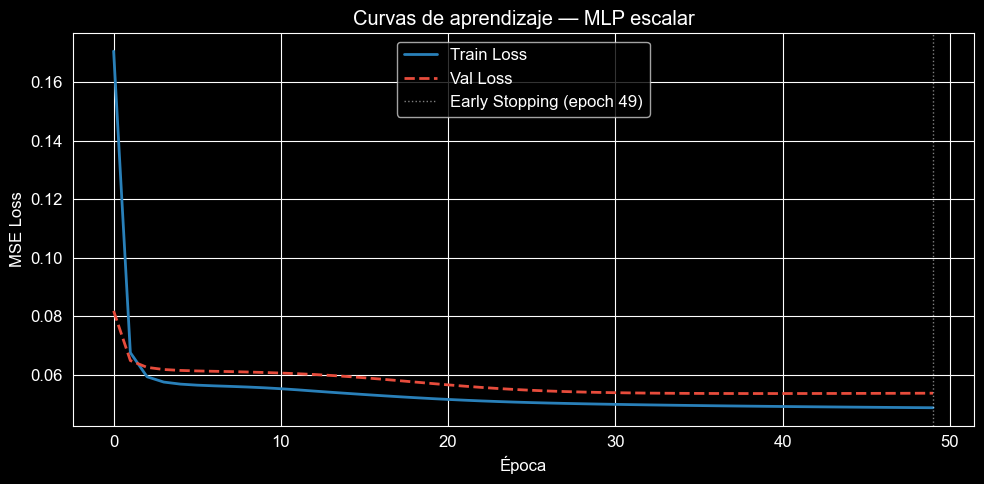

In [57]:
# TODO: Graficar las curvas de entrenamiento y validación (train_losses y val_losses vs. época).
# Curvas de aprendizaje
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='#2980b9', lw=2)
ax.plot(val_losses,   label='Val Loss',   color='#e74c3c', lw=2, linestyle='--')
ax.axvline(len(train_losses)-1, color='white', lw=1,
           linestyle=':', alpha=0.5, label=f'Early Stopping (epoch {len(train_losses)-1})')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.set_title('Curvas de aprendizaje — MLP escalar')
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
from sklearn.metrics import accuracy_score, f1_score

In [59]:
# TODO: Evaluar el modelo sobre el conjunto de Test.
# Para cada muestra, ejecutar el forward pass y aplicar umbral > 0.5 para clasificar.
# Reportar accuracy y F1-score.

# Evaluación sobre Test
y_test_pred = []

for i in range(len(X_test_s)):
    a1_0 = X_test_s[i, 0]
    a2_0 = X_test_s[i, 1]
    a3_0 = X_test_s[i, 2]

    z1_1 = w11_1*a1_0 + w12_1*a2_0 + w13_1*a3_0 + b1_1
    z2_1 = w21_1*a1_0 + w22_1*a2_0 + w23_1*a3_0 + b2_1
    z3_1 = w31_1*a1_0 + w32_1*a2_0 + w33_1*a3_0 + b3_1
    z4_1 = w41_1*a1_0 + w42_1*a2_0 + w43_1*a3_0 + b4_1

    a1_1 = sigmoid(z1_1)
    a2_1 = sigmoid(z2_1)
    a3_1 = sigmoid(z3_1)
    a4_1 = sigmoid(z4_1)

    z1_2 = w11_2*a1_1 + w12_2*a2_1 + w13_2*a3_1 + w14_2*a4_1 + b1_2
    a1_2 = sigmoid(z1_2)

    y_test_pred.append(1 if a1_2 >= 0.5 else 0)

print("=" * 45)
print("EVALUACIÓN FINAL MLP escalar sobre Test")
print("=" * 45)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_test_pred):.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_test_pred):.4f}")


EVALUACIÓN FINAL MLP escalar sobre Test
Accuracy        0.9561
F1-Score        0.9645


## 6. Conclusiones

Responda las siguientes preguntas con base en los resultados obtenidos:

1. **Efecto del escalamiento:** ¿Qué ocurriría si no se escalaran las variables antes de entrenar? Considere que `mean area` toma valores del orden de cientos/miles, mientras que `mean smoothness` está en el orden de centésimas. Explique cómo esto afecta los gradientes (recuerde que $\nabla w_{jk} = \delta_j \cdot a_k$) y la estabilidad del entrenamiento.


## 6. Conclusiones

**1. Efecto del escalamiento**

Sin escalamiento, el entrenamiento falla por dos razones encadenadas.
Esto pasa directamente en este laboratorio: con `X_train` sin escalar
el modelo quedó estancado en:

```
Epoch 0  -> Train Loss: 0.2674   Val Loss: 0.2401
Epoch 10 -> Train Loss: 0.2673   Val Loss: 0.2401  <- No cambia el valor de perdidaa
```

Con `X_train_s` (RobustScaler) el modelo convergió correctamente:

```
Epoch 0  -> Train Loss: 0.1688   Val Loss: 0.0812
Epoch 10 -> Train Loss: 0.0552   Val Loss: 0.0601
Early Stopping en epoch 49
```

**¿Por qué ocurre esto?**

El problema tiene dos efectos simultáneos sobre el gradiente
$\nabla w_{jk} = \delta_j \cdot a_k$:

**Efecto 1 Saturación de la sigmoide:**
`mean area` toma valores del orden de 500–2500. Al calcular la
pre-activación de la capa oculta:

$$z_j = w_{j1} \cdot \underbrace{a_1}_{\sim 500} + w_{j2} \cdot \underbrace{a_2}_{\sim 20} + w_{j3} \cdot \underbrace{a_3}_{\sim 0.1} + b_j$$

Con pesos iniciales $w \sim 0.1$, el término $w_{j1} \cdot 500 \approx 50$,
lo que lleva $z_j$ a valores extremos. La sigmoide satura:

$$\sigma(50) \approx 1 \quad \Rightarrow \quad \sigma'(50) = \sigma(50)(1-\sigma(50)) \approx 0$$

Con $\sigma'(z) \approx 0$, el delta de cada neurona colapsa:

$$\delta_j = \left(\sum_k w_{kj} \cdot \delta_k^{(\text{out})}\right) \cdot \sigma'(z_j) \approx 0$$

**Efecto 2 Gradientes desbalanceados:**
Incluso si la sigmoide no se saturara completamente, los gradientes
serían demasiado distintos por feature:

$$\nabla w_{j1} = \delta_j \cdot a_1 \sim \delta_j \cdot 500$$
$$\nabla w_{j3} = \delta_j \cdot a_3 \sim \delta_j \cdot 0.1$$

El peso asociado a `mean area` tendria actualizaciones ~5000 veces
mayores que el de `mean smoothness`. Con $\eta = 0.5$, esto genera
oscilaciones inestables en $w_{j1}$ mientras $w_{j3}$ prácticamente
no se mueve (Géron, 2022).

`RobustScaler` resolvió ambos problemas llevando las tres variables
a una escala comparable centrada en 0, garantizando que:

$$z_j = w_{j1} \cdot \tilde{a}_1 + w_{j2} \cdot \tilde{a}_2 + w_{j3} \cdot \tilde{a}_3 + b_j \in (-3, 3)$$

lo que mantiene $\sigma'(z_j)$ en su zona activa y los gradientes
proporcionales entre features (Bishop, 2006).

---

**Referencias**

> Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*.
> Springer.
>
> Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn,
> Keras, and TensorFlow* (3rd ed.). O'Reilly Media.